# Práctica 07
## Pronóstico de Riesgo de Infarto en los Próximos 6 Meses en Xicotepec de Juárez

### Objetivo

Desarrollar un modelo de aprendizaje supervisado para predecir el nivel de riesgo de infarto en pacientes del municipio de Xicotepec de Juárez utilizando variables clínicas, demográficas y geográficas contenidas en un dataset simulado.

In [1]:
# ==========================================
# Importación de librerías
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

Cargar el dataset

In [2]:
# ==========================================
# Cargar dataset
# ==========================================

df = pd.read_csv("dataset_unificado.csv")

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


Pimeros registros

In [3]:
df.head()

,ID_Paciente,CURP,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo,Estatura_m,Peso_kg,...,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud,Riesgo_Infarto
0,PAC-00001,RORL681104HPL2UTXE,Luis,Rodriguez,Ramirez,1968-11-04,58,M,1.64,72.4,...,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.25676,-97.92826,Alto
1,PAC-00002,REVP730124MPLO28WX,Patricia,Reyes,Vazquez,1973-01-24,53,F,1.69,88.5,...,0,0,0,1,1,Xicotepec de Juárez,Sierra Norte,20.30251,-97.94065,Medio
2,PAC-00003,LOJS840508MPLLYO76,Sofia,Lopez,Jimenez,1984-05-08,42,F,1.64,83.9,...,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.30936,-97.99931,Alto
3,PAC-00004,RERE740405MPL1YFGU,Elena,Reyes,Reyes,1974-04-05,52,F,1.69,71.1,...,0,0,0,0,0,Ajalpan,Otras Regiones,18.60916,-97.60045,Medio
4,PAC-00005,SASJ851204HPLQGQ9A,Jose,Sanchez,Sanchez,1985-12-04,41,M,1.73,79.1,...,0,0,0,1,0,Puebla,Otras Regiones,19.43582,-98.14650,Bajo


Últimos registros

In [4]:
df.tail()

,ID_Paciente,CURP,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo,Estatura_m,Peso_kg,...,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud,Riesgo_Infarto
24995,PAC-24996,CRRA670524HPLVXS0E,Antonio,Cruz,Reyes,1967-05-24,59,M,1.70,75.8,...,0,1,0,0,0,Puebla,Otras Regiones,18.74856,-98.34042,Alto
24996,PAC-24997,GOGG920815MPLUGOUH,Guadalupe,Gonzalez,Gomez,1992-08-15,34,F,1.69,70.8,...,1,0,0,0,0,Zacatlán,Otras Regiones,19.05184,-97.58758,Medio
24997,PAC-24998,VAPI520219MPLP4G99,Isabel,Vazquez,Perez,1952-02-19,74,F,1.49,51.8,...,0,1,0,1,0,Puebla,Otras Regiones,19.16549,-98.03477,Alto
24998,PAC-24999,RESS600930MPLAWBV0,Sofia,Reyes,Sanchez,1960-09-30,66,F,1.68,76.4,...,0,1,1,1,0,Xicotepec de Juárez,Sierra Norte,20.27487,-97.97501,Alto
24999,PAC-25000,HEPI710917MPLYIPYK,Isabel,Hernandez,Perez,1971-09-17,55,F,1.72,92.7,...,0,1,0,0,1,Puebla,Otras Regiones,18.67228,-98.16746,Alto


Dimensiones

In [5]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 25000
Número de columnas: 26


Información general

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Paciente           25000 non-null  object 
 1   CURP                  25000 non-null  object 
 2   Nombre                25000 non-null  object 
 3   Apellido_Paterno      25000 non-null  object 
 4   Apellido_Materno      25000 non-null  object 
 5   Fecha_Nacimiento      25000 non-null  object 
 6   Edad                  25000 non-null  int64  
 7   Sexo                  25000 non-null  object 
 8   Estatura_m            25000 non-null  float64
 9   Peso_kg               25000 non-null  float64
 10  IMC                   25000 non-null  float64
 11  Presion_Sistolica     25000 non-null  int64  
 12  Presion_Diastolica    25000 non-null  int64  
 13  Glucosa               25000 non-null  int64  
 14  Colesterol            25000 non-null  int64  
 15  Frecuencia_Cardiaca

Tipos de datos

In [7]:
df.dtypes.to_frame("Tipo de dato")

,Tipo de dato
ID_Paciente,object
CURP,object
Nombre,object
Apellido_Paterno,object
Apellido_Materno,object
Fecha_Nacimiento,object
Edad,int64
Sexo,object
Estatura_m,float64
Peso_kg,float64


Valores faltantes

In [27]:
valores_nulos = df.isnull().sum().sort_values(ascending=False)

valores_nulos.to_frame("Valores nulos")

,Valores nulos
ID_Paciente,0
CURP,0
Longitud,0
Latitud,0
Region,0
Municipio,0
Antecedente_Familiar,0
Actividad_Fisica,0
Fumador,0
Hipertension,0


Porcentajes nulos

In [28]:
porcentaje_nulos = (df.isnull().sum()/len(df))*100

porcentaje_nulos.sort_values(ascending=False).round(2)

ID_Paciente             0.0
CURP                    0.0
Longitud                0.0
Latitud                 0.0
Region                  0.0
Municipio               0.0
Antecedente_Familiar    0.0
Actividad_Fisica        0.0
Fumador                 0.0
Hipertension            0.0
Diabetes                0.0
Frecuencia_Cardiaca     0.0
Colesterol              0.0
Glucosa                 0.0
Presion_Diastolica      0.0
Presion_Sistolica       0.0
IMC                     0.0
Peso_kg                 0.0
Estatura_m              0.0
Sexo                    0.0
Edad                    0.0
Fecha_Nacimiento        0.0
Apellido_Materno        0.0
Apellido_Paterno        0.0
Nombre                  0.0
Riesgo_Infarto          0.0
dtype: float64

Estadísticas descriptivas

In [30]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_Paciente,25000,25000,PAC-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURP,25000,25000,RORL681104HPL2UTXE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre,25000,20,Laura,1329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Apellido_Paterno,25000,16,Martinez,1632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Apellido_Materno,25000,16,Sanchez,1627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha_Nacimiento,25000,14403,1982-10-05,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,25000.0,NaN,NaN,NaN,51.49648,14.742815,18.0,41.0,52.0,62.0,90.0
Sexo,25000,2,F,12806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatura_m,25000.0,NaN,NaN,NaN,1.650156,0.079955,1.29,1.6,1.65,1.7,1.96
Peso_kg,25000.0,NaN,NaN,NaN,71.002048,12.884441,29.0,62.1,70.4,79.3,131.0


In [31]:
for columna in df.columns:
    print(columna)

ID_Paciente
CURP
Nombre
Apellido_Paterno
Apellido_Materno
Fecha_Nacimiento
Edad
Sexo
Estatura_m
Peso_kg
IMC
Presion_Sistolica
Presion_Diastolica
Glucosa
Colesterol
Frecuencia_Cardiaca
Diabetes
Hipertension
Fumador
Actividad_Fisica
Antecedente_Familiar
Municipio
Region
Latitud
Longitud
Riesgo_Infarto


Municipios disponibles

In [32]:
df["Municipio"].value_counts()

Municipio
Xicotepec de Juárez    9918
Huauchinango           5069
Zacatlán               3727
Puebla                 2589
Teziutlán              2548
Ajalpan                1149
Name: count, dtype: int64

Filtrar Xicotepec

In [8]:
df_xico = df[df["Municipio"] == "Xicotepec de Juárez"].copy()

print(f"Pacientes de Xicotepec: {len(df_xico)}")

Pacientes de Xicotepec: 9918


In [9]:
df_xico.head()

,ID_Paciente,CURP,Nombre,Apellido_Paterno,Apellido_Materno,Fecha_Nacimiento,Edad,Sexo,Estatura_m,Peso_kg,...,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud,Riesgo_Infarto
0,PAC-00001,RORL681104HPL2UTXE,Luis,Rodriguez,Ramirez,1968-11-04,58,M,1.64,72.4,...,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.25676,-97.92826,Alto
1,PAC-00002,REVP730124MPLO28WX,Patricia,Reyes,Vazquez,1973-01-24,53,F,1.69,88.5,...,0,0,0,1,1,Xicotepec de Juárez,Sierra Norte,20.30251,-97.94065,Medio
2,PAC-00003,LOJS840508MPLLYO76,Sofia,Lopez,Jimenez,1984-05-08,42,F,1.64,83.9,...,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.30936,-97.99931,Alto
5,PAC-00006,MAGA861124HPL1IYR8,Antonio,Martinez,Gomez,1986-11-24,40,M,1.69,71.2,...,1,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25919,-97.94677,Alto
6,PAC-00007,CRMJ800903HPLA92VN,Juan,Cruz,Morales,1980-09-03,46,M,1.55,58.4,...,0,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25042,-97.94491,Alto


Validar volumen

In [10]:
print("Dimensiones del nuevo dataset:")

df_xico.shape

Dimensiones del nuevo dataset:


(9918, 26)

Variables clínicas

In [11]:
variables_clinicas = [

    "Edad",
    "Estatura_m",
    "Peso_kg",
    "IMC",
    "Presion_Sistolica",
    "Presion_Diastolica",
    "Glucosa",
    "Colesterol",
    "Frecuencia_Cardiaca",
    "Diabetes",
    "Hipertension",
    "Fumador",
    "Actividad_Fisica",
    "Antecedente_Familiar"

]

df_xico[variables_clinicas].head()

,Edad,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar
0,58,1.64,72.4,26.9,147,98,87,200,69,0,1,0,0,1
1,53,1.69,88.5,31.0,119,75,74,158,71,0,0,0,1,1
2,42,1.64,83.9,31.2,142,86,110,162,78,0,1,0,0,1
5,40,1.69,71.2,24.9,130,86,158,183,61,1,1,1,0,0
6,46,1.55,58.4,24.3,130,102,77,191,65,0,1,1,0,0


In [12]:
variables_geograficas = [

    "Latitud",
    "Longitud"

]

df_xico[variables_geograficas].head()

,Latitud,Longitud
0,20.25676,-97.92826
1,20.30251,-97.94065
2,20.30936,-97.99931
5,20.25919,-97.94677
6,20.25042,-97.94491


In [41]:
df_xico.describe()  # Por defecto solo incluye las numéricas y elimina los NaN de texto

,Edad,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Latitud,Longitud
count,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.00000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000,9918.000000
mean,51.338879,1.650210,71.124299,26.060224,132.601432,84.795523,97.224541,194.66949,71.445150,0.161625,0.427102,0.250958,0.404719,0.294112,20.285031,-97.960495
std,14.797623,0.079668,12.911495,4.006796,10.510406,7.214621,24.776726,35.63369,8.058133,0.368125,0.494682,0.433586,0.490862,0.455665,0.020090,0.022963
min,18.000000,1.290000,30.600000,10.900000,94.000000,58.000000,8.000000,56.00000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.250000,-98.000000
25%,41.000000,1.600000,62.300000,23.400000,125.000000,80.000000,81.000000,171.00000,66.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.267762,-97.980530
50%,51.000000,1.650000,70.500000,26.100000,133.000000,85.000000,97.000000,195.00000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.285215,-97.960775
75%,61.750000,1.700000,79.600000,28.800000,140.000000,90.000000,114.000000,218.00000,77.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.302230,-97.940832
max,90.000000,1.950000,131.000000,42.800000,170.000000,110.000000,181.000000,339.00000,102.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.319980,-97.920010


# Preparación del Dataset

En esta sección se prepara el conjunto de datos para el entrenamiento de modelos de aprendizaje supervisado.

Se verificará la variable objetivo, se seleccionarán las variables predictoras, se codificarán los atributos categóricos y se normalizarán las variables numéricas.

In [13]:
# Variable objetivo

df_xico["Riesgo_Infarto"].value_counts()

Riesgo_Infarto
Medio      4365
Bajo       2699
Alto       2459
Crítico     395
Name: count, dtype: int64

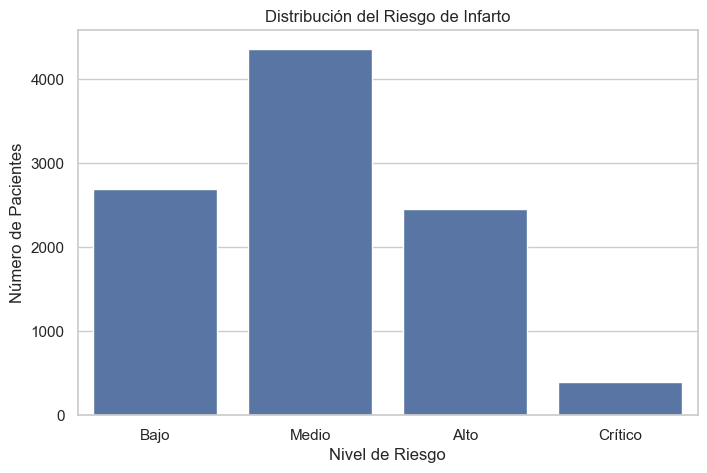

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_xico,
    x="Riesgo_Infarto",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Distribución del Riesgo de Infarto")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Número de Pacientes")

plt.show()

In [15]:
riesgo = (
    df_xico["Riesgo_Infarto"]
    .value_counts(normalize=True)
    *100
)

riesgo.round(2)

Riesgo_Infarto
Medio      44.01
Bajo       27.21
Alto       24.79
Crítico     3.98
Name: proportion, dtype: float64

In [16]:
nulos = df_xico.isnull().sum()

nulos[nulos>0]

Series([], dtype: int64)

In [17]:
print("Registros duplicados:", df_xico.duplicated().sum())

Registros duplicados: 0


In [18]:
df_xico = df_xico.drop_duplicates()

print(df_xico.shape)

(9918, 26)


In [19]:
columnas_eliminar = [

    "ID_Paciente",
    "CURP",
    "Nombre",
    "Apellido_Paterno",
    "Apellido_Materno",
    "Fecha_Nacimiento"

]

df_modelo = df_xico.drop(columns=columnas_eliminar)

df_modelo.head()

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud,Riesgo_Infarto
0,58,M,1.64,72.4,26.9,147,98,87,200,69,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.25676,-97.92826,Alto
1,53,F,1.69,88.5,31.0,119,75,74,158,71,0,0,0,1,1,Xicotepec de Juárez,Sierra Norte,20.30251,-97.94065,Medio
2,42,F,1.64,83.9,31.2,142,86,110,162,78,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.30936,-97.99931,Alto
5,40,M,1.69,71.2,24.9,130,86,158,183,61,1,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25919,-97.94677,Alto
6,46,M,1.55,58.4,24.3,130,102,77,191,65,0,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25042,-97.94491,Alto


In [20]:
X = df_modelo.drop(columns=["Riesgo_Infarto"])

X.head()

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud
0,58,M,1.64,72.4,26.9,147,98,87,200,69,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.25676,-97.92826
1,53,F,1.69,88.5,31.0,119,75,74,158,71,0,0,0,1,1,Xicotepec de Juárez,Sierra Norte,20.30251,-97.94065
2,42,F,1.64,83.9,31.2,142,86,110,162,78,0,1,0,0,1,Xicotepec de Juárez,Sierra Norte,20.30936,-97.99931
5,40,M,1.69,71.2,24.9,130,86,158,183,61,1,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25919,-97.94677
6,46,M,1.55,58.4,24.3,130,102,77,191,65,0,1,1,0,0,Xicotepec de Juárez,Sierra Norte,20.25042,-97.94491


In [21]:
y = df_modelo["Riesgo_Infarto"]

y.head()

0     Alto
1    Medio
2     Alto
5     Alto
6     Alto
Name: Riesgo_Infarto, dtype: object

In [22]:
X.select_dtypes(include="object").columns

Index(['Sexo', 'Municipio', 'Region'], dtype='object')

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X_codificado = X.copy()

columnas_categoricas = X_codificado.select_dtypes(include="object").columns

for columna in columnas_categoricas:
    X_codificado[columna] = encoder.fit_transform(X_codificado[columna])

X_codificado.head()

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud
0,58,1,1.64,72.4,26.9,147,98,87,200,69,0,1,0,0,1,0,0,20.25676,-97.92826
1,53,0,1.69,88.5,31.0,119,75,74,158,71,0,0,0,1,1,0,0,20.30251,-97.94065
2,42,0,1.64,83.9,31.2,142,86,110,162,78,0,1,0,0,1,0,0,20.30936,-97.99931
5,40,1,1.69,71.2,24.9,130,86,158,183,61,1,1,1,0,0,0,0,20.25919,-97.94677
6,46,1,1.55,58.4,24.3,130,102,77,191,65,0,1,1,0,0,0,0,20.25042,-97.94491


In [ ]:
X_codificado.dtypes

In [24]:
variables_numericas = [

    "Edad",
    "IMC",
    "Presion_Sistolica",
    "Presion_Diastolica",
    "Glucosa",
    "Colesterol",
    "Frecuencia_Cardiaca"

]

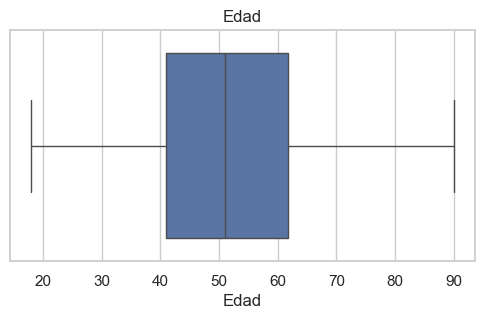

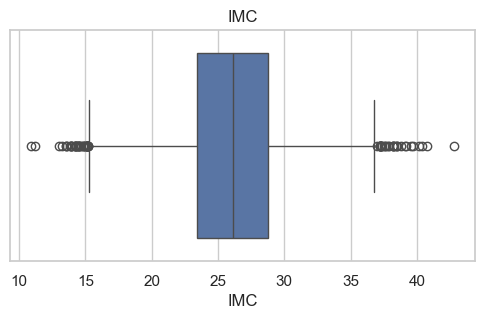

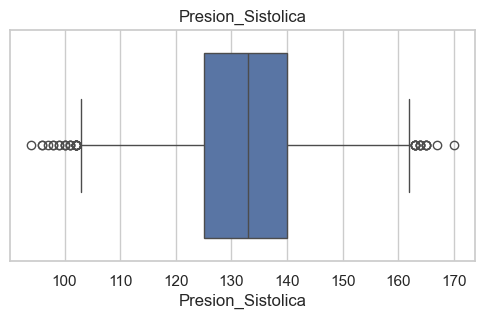

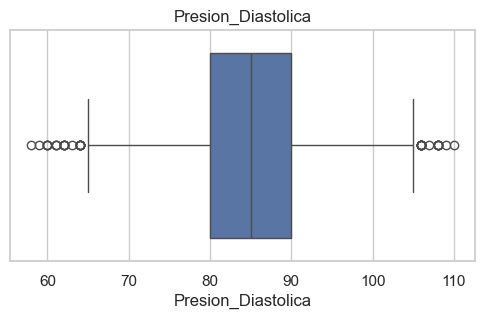

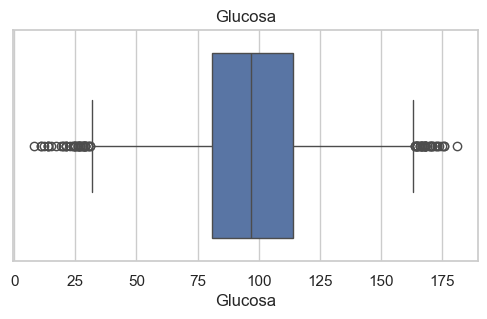

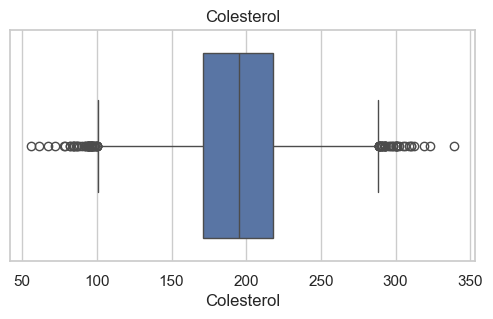

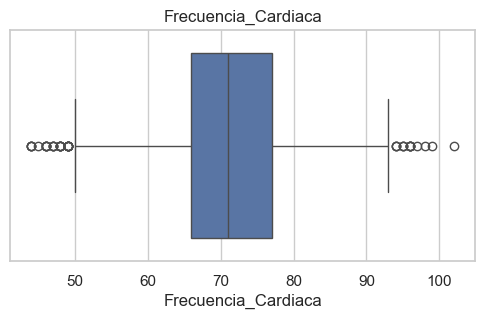

In [25]:
for variable in variables_numericas:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=X_codificado[variable])

    plt.title(variable)

    plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_escalado = X_codificado.copy()

X_escalado[variables_numericas] = scaler.fit_transform(
    X_escalado[variables_numericas]
)

X_escalado.head()

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud
0,0.450171,1,1.64,72.4,0.209599,1.370004,1.830331,-0.412688,0.149599,-0.303454,0,1,0,0,1,0,0,20.25676,-97.92826
1,0.112262,0,1.69,88.5,1.232912,-1.294157,-1.357801,-0.937400,-1.029120,-0.055245,0,0,0,1,1,0,0,20.30251,-97.94065
2,-0.631138,0,1.64,83.9,1.282829,0.894261,0.166958,0.515649,-0.916861,0.813486,0,1,0,0,1,0,0,20.30936,-97.99931
5,-0.766302,1,1.69,71.2,-0.289579,-0.247523,0.166958,2.453049,-0.327501,-1.296290,1,1,1,0,0,0,0,20.25919,-97.94677
6,-0.360811,1,1.55,58.4,-0.439332,-0.247523,2.384788,-0.816313,-0.102983,-0.799872,0,1,1,0,0,0,0,20.25042,-97.94491


In [27]:
X_escalado.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,9918.0,6.447756e-17,1.000050,-2.253102,-0.698720,-0.022902,0.703603,2.612789
Sexo,9918.0,4.927405e-01,0.499973,0.000000,0.000000,0.000000,1.000000,1.000000
Estatura_m,9918.0,1.650210e+00,0.079668,1.290000,1.600000,1.650000,1.700000,1.950000
Peso_kg,9918.0,7.112430e+01,12.911495,30.600000,62.300000,70.500000,79.600000,131.000000
IMC,9918.0,-4.155221e-17,1.000050,-3.783818,-0.663961,0.009928,0.683817,4.178057
Presion_Sistolica,9918.0,9.313426e-17,1.000050,-3.672872,-0.723266,0.037923,0.703963,3.558421
Presion_Diastolica,9918.0,4.885966e-16,1.000050,-3.714246,-0.664729,0.028343,0.721415,3.493704
Glucosa,9918.0,3.868654e-17,1.000050,-3.601325,-0.654863,-0.009063,0.677099,3.381386
Colesterol,9918.0,9.743276e-17,1.000050,-3.891724,-0.664278,0.009276,0.654765,4.050599
Frecuencia_Cardiaca,9918.0,1.002984e-17,1.000050,-3.406066,-0.675768,-0.055245,0.689382,3.791994


In [28]:
dataset_modelo = X_escalado.copy()

dataset_modelo["Riesgo_Infarto"] = y.values

dataset_modelo.head()

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud,Riesgo_Infarto
0,0.450171,1,1.64,72.4,0.209599,1.370004,1.830331,-0.412688,0.149599,-0.303454,0,1,0,0,1,0,0,20.25676,-97.92826,Alto
1,0.112262,0,1.69,88.5,1.232912,-1.294157,-1.357801,-0.937400,-1.029120,-0.055245,0,0,0,1,1,0,0,20.30251,-97.94065,Medio
2,-0.631138,0,1.64,83.9,1.282829,0.894261,0.166958,0.515649,-0.916861,0.813486,0,1,0,0,1,0,0,20.30936,-97.99931,Alto
5,-0.766302,1,1.69,71.2,-0.289579,-0.247523,0.166958,2.453049,-0.327501,-1.296290,1,1,1,0,0,0,0,20.25919,-97.94677,Alto
6,-0.360811,1,1.55,58.4,-0.439332,-0.247523,2.384788,-0.816313,-0.102983,-0.799872,0,1,1,0,0,0,0,20.25042,-97.94491,Alto


In [29]:
import os

os.makedirs("data/processed", exist_ok=True)

dataset_modelo.to_csv(
    "data/processed/dataset_modelado_xicotepec.csv",
    index=False
)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


In [30]:
print("Filas:", dataset_modelo.shape[0])
print("Columnas:", dataset_modelo.shape[1])

dataset_modelo.info()

Filas: 9918
Columnas: 20
<class 'pandas.core.frame.DataFrame'>
Index: 9918 entries, 0 to 24998
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Edad                  9918 non-null   float64
 1   Sexo                  9918 non-null   int64  
 2   Estatura_m            9918 non-null   float64
 3   Peso_kg               9918 non-null   float64
 4   IMC                   9918 non-null   float64
 5   Presion_Sistolica     9918 non-null   float64
 6   Presion_Diastolica    9918 non-null   float64
 7   Glucosa               9918 non-null   float64
 8   Colesterol            9918 non-null   float64
 9   Frecuencia_Cardiaca   9918 non-null   float64
 10  Diabetes              9918 non-null   int64  
 11  Hipertension          9918 non-null   int64  
 12  Fumador               9918 non-null   int64  
 13  Actividad_Fisica      9918 non-null   int64  
 14  Antecedente_Familiar  9918 non-null   int64  
 15  

# Análisis Exploratorio de Datos (EDA)

En esta sección se realiza un análisis exploratorio del dataset preparado con el objetivo de identificar patrones, distribuciones y relaciones entre las variables clínicas y el nivel de riesgo de infarto.

Estadísticas descriptivas

In [31]:
# ======================================
# Estadísticas descriptivas
# ======================================

dataset_modelo.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,9918.0,6.447756e-17,1.000050,-2.253102,-0.698720,-0.022902,0.703603,2.612789
Sexo,9918.0,4.927405e-01,0.499973,0.000000,0.000000,0.000000,1.000000,1.000000
Estatura_m,9918.0,1.650210e+00,0.079668,1.290000,1.600000,1.650000,1.700000,1.950000
Peso_kg,9918.0,7.112430e+01,12.911495,30.600000,62.300000,70.500000,79.600000,131.000000
IMC,9918.0,-4.155221e-17,1.000050,-3.783818,-0.663961,0.009928,0.683817,4.178057
Presion_Sistolica,9918.0,9.313426e-17,1.000050,-3.672872,-0.723266,0.037923,0.703963,3.558421
Presion_Diastolica,9918.0,4.885966e-16,1.000050,-3.714246,-0.664729,0.028343,0.721415,3.493704
Glucosa,9918.0,3.868654e-17,1.000050,-3.601325,-0.654863,-0.009063,0.677099,3.381386
Colesterol,9918.0,9.743276e-17,1.000050,-3.891724,-0.664278,0.009276,0.654765,4.050599
Frecuencia_Cardiaca,9918.0,1.002984e-17,1.000050,-3.406066,-0.675768,-0.055245,0.689382,3.791994


Distribución de la edad

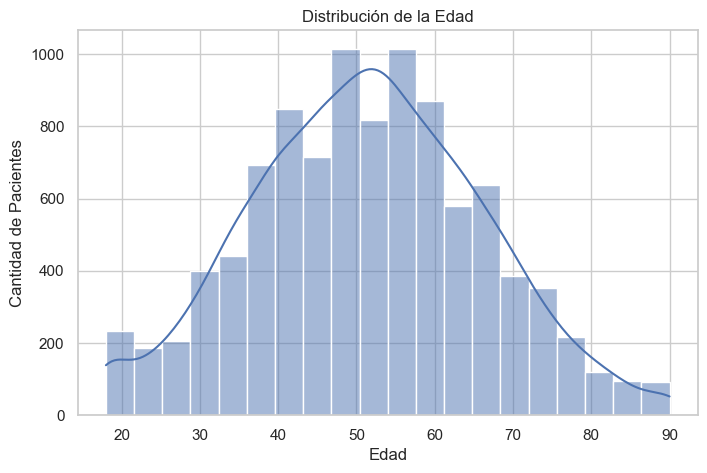

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_xico,
    x="Edad",
    bins=20,
    kde=True
)

plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Pacientes")

plt.show()

Distribución del IMC

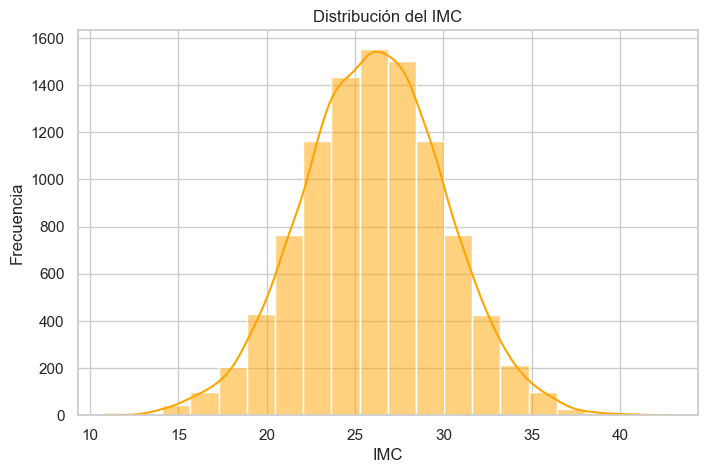

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_xico,
    x="IMC",
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Distribución del IMC")
plt.xlabel("IMC")
plt.ylabel("Frecuencia")

plt.show()

Distribución del riesgo

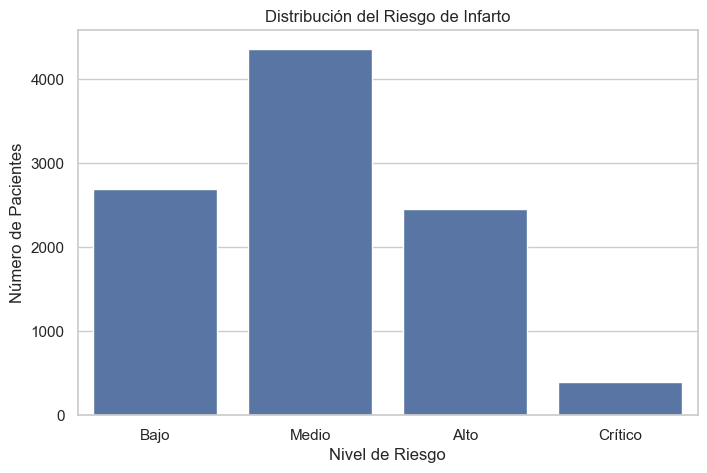

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_xico,
    x="Riesgo_Infarto",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Distribución del Riesgo de Infarto")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Número de Pacientes")

plt.show()

Riesgo por sexo

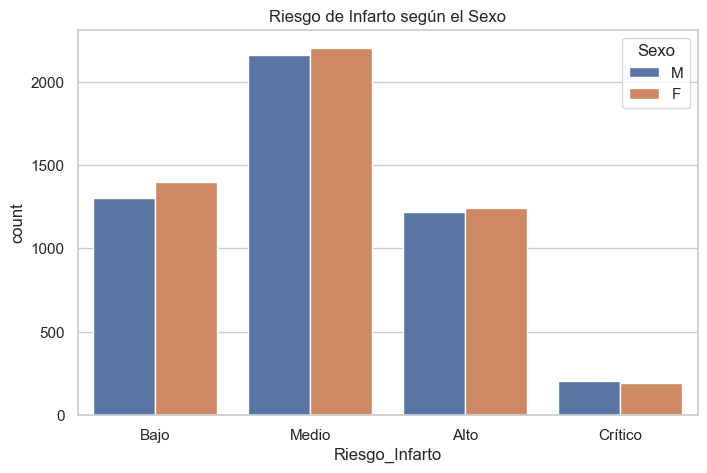

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_xico,
    x="Riesgo_Infarto",
    hue="Sexo",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Riesgo de Infarto según el Sexo")

plt.show()

Edad respecto al riesgo

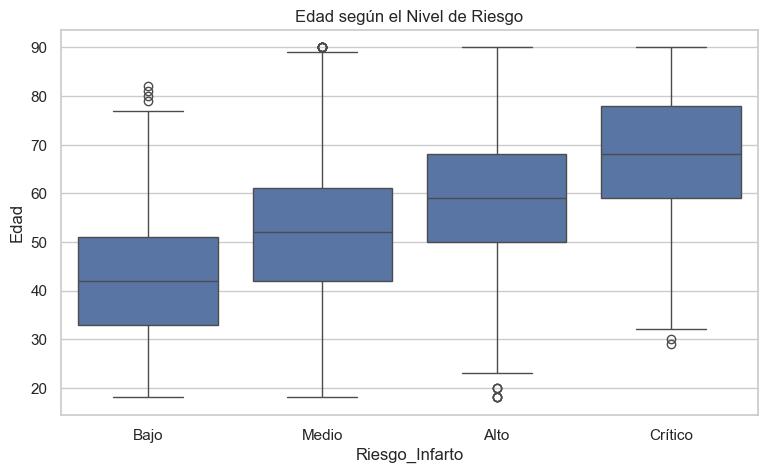

In [36]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_xico,
    x="Riesgo_Infarto",
    y="Edad",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Edad según el Nivel de Riesgo")

plt.show()

IMC respecto al riesgo

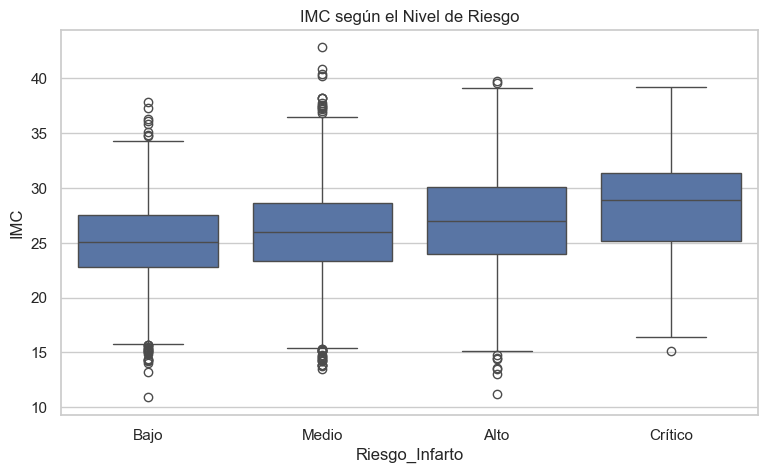

In [37]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_xico,
    x="Riesgo_Infarto",
    y="IMC",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("IMC según el Nivel de Riesgo")

plt.show()

Presión sistólica respecto al riesgo

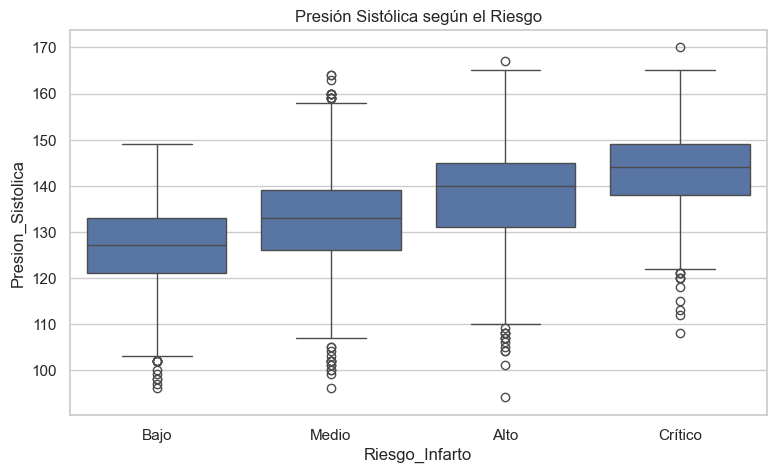

In [38]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_xico,
    x="Riesgo_Infarto",
    y="Presion_Sistolica",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Presión Sistólica según el Riesgo")

plt.show()

Presión diastólica respecto al riesgo

Glucosa respecto al riesgo

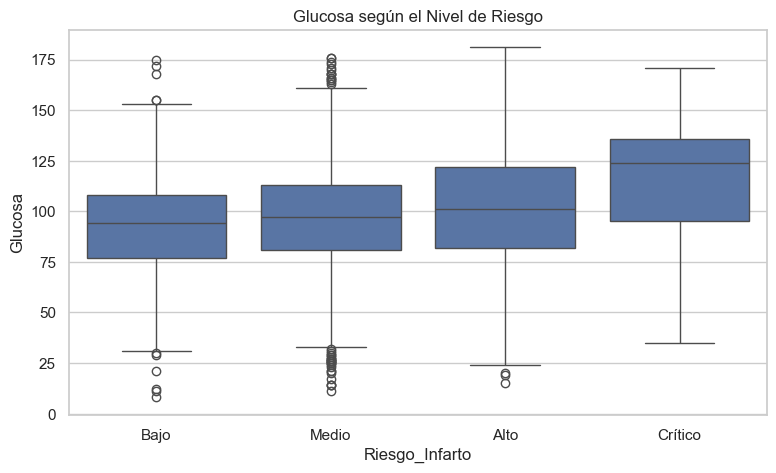

In [39]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_xico,
    x="Riesgo_Infarto",
    y="Glucosa",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Glucosa según el Nivel de Riesgo")

plt.show()

Colesterol respecto al riesgo

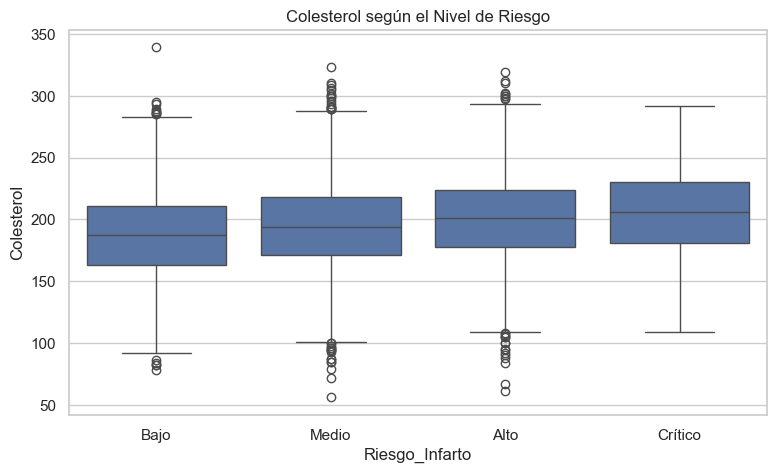

In [40]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_xico,
    x="Riesgo_Infarto",
    y="Colesterol",
    order=["Bajo","Medio","Alto","Crítico"]
)

plt.title("Colesterol según el Nivel de Riesgo")

plt.show()

Frecuencia cardíaca

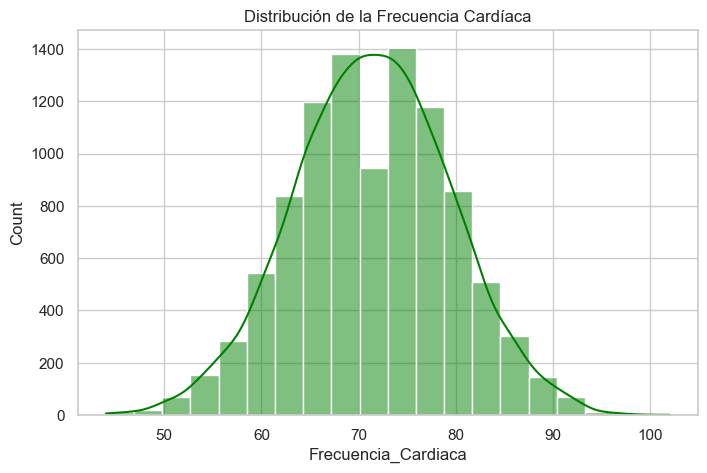

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_xico,
    x="Frecuencia_Cardiaca",
    bins=20,
    kde=True,
    color="green"
)

plt.title("Distribución de la Frecuencia Cardíaca")

plt.show()

Correlación

In [42]:
correlacion = dataset_modelo.corr(numeric_only=True)

correlacion

,Edad,Sexo,Estatura_m,Peso_kg,IMC,Presion_Sistolica,Presion_Diastolica,Glucosa,Colesterol,Frecuencia_Cardiaca,Diabetes,Hipertension,Fumador,Actividad_Fisica,Antecedente_Familiar,Municipio,Region,Latitud,Longitud
Edad,1.000000,0.014637,0.003197,0.007129,0.005740,0.282833,0.201368,0.005844,0.132592,0.002055,0.007363,0.197228,-0.014906,0.005938,0.004554,NaN,NaN,0.006462,0.014346
Sexo,0.014637,1.000000,-0.005379,0.010660,0.013857,-0.000886,0.002076,0.008927,-0.006661,-0.005818,0.006102,0.003976,-0.002061,-0.001586,0.001627,NaN,NaN,0.001383,-0.013194
Estatura_m,0.003197,-0.005379,1.000000,0.524189,-0.007612,-0.002965,-0.009752,-0.010058,-0.010045,-0.006405,0.000735,-0.020107,-0.001932,0.002625,0.008189,NaN,NaN,0.009520,-0.000434
Peso_kg,0.007129,0.010660,0.524189,1.000000,0.843407,0.086257,0.100174,0.060504,0.002520,0.003541,0.027178,0.084160,0.002277,0.009644,-0.004691,NaN,NaN,-0.001289,-0.006921
IMC,0.005740,0.013857,-0.007612,0.843407,1.000000,0.105422,0.123684,0.078033,0.008593,0.007894,0.031103,0.112553,0.003100,0.009263,-0.010216,NaN,NaN,-0.006960,-0.007067
Presion_Sistolica,0.282833,-0.000886,-0.002965,0.086257,0.105422,1.000000,0.071144,0.012709,0.036812,-0.005400,-0.009724,0.467680,-0.005022,-0.009072,-0.006746,NaN,NaN,-0.003091,0.001003
Presion_Diastolica,0.201368,0.002076,-0.009752,0.100174,0.123684,0.071144,1.000000,0.018401,0.012743,0.005904,0.003978,0.449526,0.005510,-0.000120,0.003327,NaN,NaN,0.016869,0.005719
Glucosa,0.005844,0.008927,-0.010058,0.060504,0.078033,0.012709,0.018401,1.000000,0.008824,0.002734,0.512182,0.017786,0.000470,0.000114,-0.005243,NaN,NaN,-0.011950,-0.006696
Colesterol,0.132592,-0.006661,-0.010045,0.002520,0.008593,0.036812,0.012743,0.008824,1.000000,0.003216,0.010107,0.024650,0.003072,0.026949,-0.013737,NaN,NaN,0.003839,0.006514
Frecuencia_Cardiaca,0.002055,-0.005818,-0.006405,0.003541,0.007894,-0.005400,0.005904,0.002734,0.003216,1.000000,-0.000461,0.002285,-0.001269,0.000336,0.013333,NaN,NaN,0.000792,0.003987


Mapa de calor de correlación

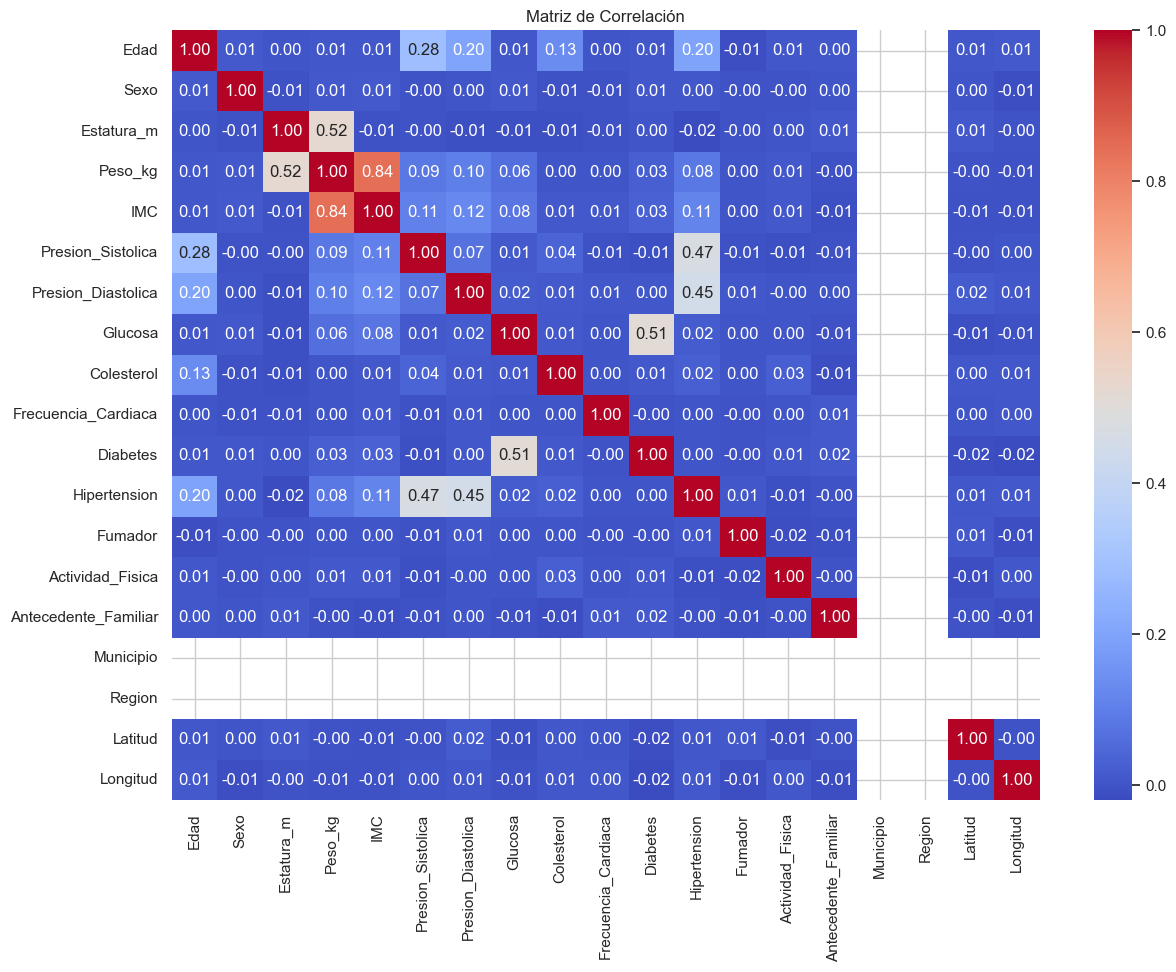

In [43]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación")

plt.show()

Variables más correlacionadas con el riesgo

In [44]:
riesgo_num = df_xico["Riesgo_Infarto"].map({
    "Bajo":1,
    "Medio":2,
    "Alto":3,
    "Crítico":4
})

df_cor = df_xico.copy()

df_cor["Riesgo_Num"] = riesgo_num

In [45]:
columnas = [
    "Edad",
    "IMC",
    "Presion_Sistolica",
    "Presion_Diastolica",
    "Glucosa",
    "Colesterol",
    "Frecuencia_Cardiaca",
    "Riesgo_Num"
]

corr = df_cor[columnas].corr()

corr["Riesgo_Num"].sort_values(ascending=False)

Riesgo_Num             1.000000
Edad                   0.470816
Presion_Sistolica      0.438329
Presion_Diastolica     0.299507
IMC                    0.213635
Glucosa                0.189649
Colesterol             0.155819
Frecuencia_Cardiaca   -0.001686
Name: Riesgo_Num, dtype: float64

Scatter Edad vs Glucosa

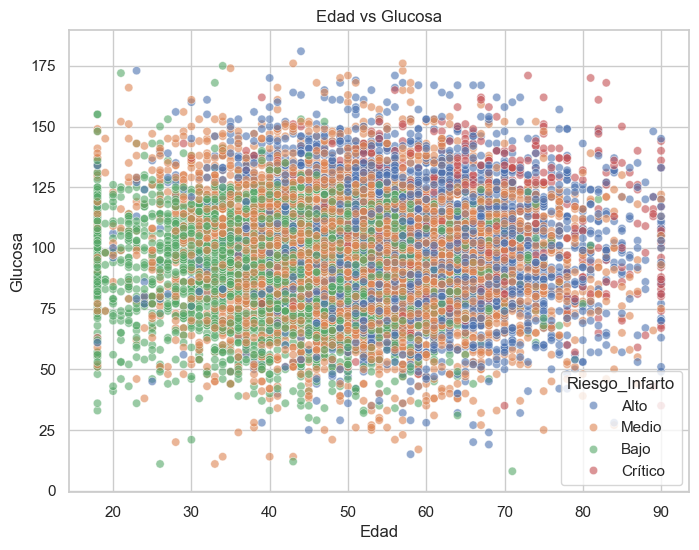

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_xico,
    x="Edad",
    y="Glucosa",
    hue="Riesgo_Infarto",
    alpha=0.6
)

plt.title("Edad vs Glucosa")

plt.show()

Scatter Colesterol vs Presión

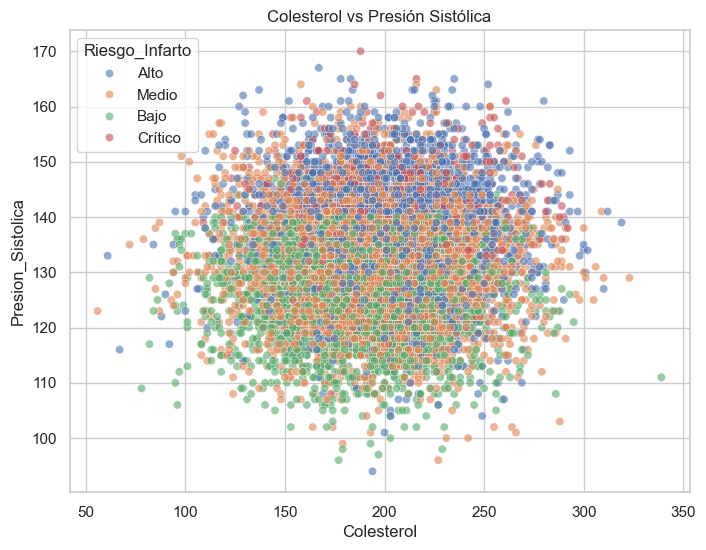

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_xico,
    x="Colesterol",
    y="Presion_Sistolica",
    hue="Riesgo_Infarto",
    alpha=0.6
)

plt.title("Colesterol vs Presión Sistólica")

plt.show()

## Interpretación del análisis exploratorio

Del análisis exploratorio se observa que los pacientes clasificados con riesgo **Alto** y **Crítico** presentan, en promedio:

- Mayor edad.
- Índices de masa corporal más elevados.
- Presión arterial más alta.
- Niveles superiores de glucosa y colesterol.
- Mayor presencia de factores de riesgo como hipertensión y diabetes.

Estos patrones indican que las variables clínicas poseen capacidad predictiva y justifican la aplicación de modelos de aprendizaje supervisado para estimar el nivel de riesgo cardiovascular.

# Entrenamiento de Modelos de Machine Learning

En esta sección se entrenarán tres algoritmos de clasificación supervisada para predecir el nivel de riesgo de infarto:

- Regresión Logística
- Random Forest
- K-Nearest Neighbors (KNN)

Posteriormente se evaluará el desempeño de cada uno mediante distintas métricas.

In [48]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [49]:
# Separar entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_escalado,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (7934, 19)
Prueba: (1984, 19)


In [50]:
modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
pred_lr = modelo_lr.predict(X_test)

In [52]:
accuracy_lr = accuracy_score(y_test, pred_lr)

precision_lr = precision_score(
    y_test,
    pred_lr,
    average="weighted"
)

recall_lr = recall_score(
    y_test,
    pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    pred_lr,
    average="weighted"
)

print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Accuracy : 0.8986895161290323
Precision: 0.8986109159999414
Recall   : 0.8986895161290323
F1 Score : 0.8982209528116851


In [53]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

        Alto       0.88      0.87      0.88       492
        Bajo       0.93      0.92      0.92       540
     Crítico       0.88      0.71      0.78        79
       Medio       0.89      0.92      0.90       873

    accuracy                           0.90      1984
   macro avg       0.89      0.85      0.87      1984
weighted avg       0.90      0.90      0.90      1984



In [54]:
modelo_rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

modelo_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
